# Playground

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)

In [87]:
import os
import sys
from pathlib import Path
import time
import json
import numpy as np
import diffusers
import xarray as xr
sys.path.append(os.path.abspath("../diffusionsim"))
import torch
import torch.nn as nn
from dataclasses import dataclass, asdict, field
import matplotlib.pyplot as plt
from pprint import pprint
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [88]:
import diffusionsim.training_utils as tru
import diffusionsim.trainers as trainers
import diffusionsim.mydatasets as data
import diffusionsim.evaluations as evals
import diffusionsim as diff

# Debugging Training Classes

In [89]:
REF_BATCH_SIZE = 128
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
#exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
in_notebook = True
dataset_type="climsim"

## Diffusion Training

In [90]:

def setup_diffusion_run(num_models, exp_id, base_run_id, data_vars='v1', image_dim=1, batch_size=128, shuffle_indices=False, use_tendencies=False):
    dataset_type = "climsim_diffusion1d"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, shuffle_indices, dataset_type, batch_size, use_tendencies)
    dconfig.train_test_split = [0.8]
    tconfigs, mconfigs = [], []

    learning_rates = [1e-5, 1e-5, 1e-5, 1e-5]
    unet_layers_per_block = [1, 1, 2, 2, 1]
    block_out_channels = [
        (32, 32, 64),
        (16, 32, 48),
        (16, 32, 64),
        (32, 48, 64),
    ]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.lr_scheduler = "cosine"
        tconfig.lr_warmup_steps = 200
        tconfig.max_T_sample = 51
        tconfig.clip_gradients = True

        unet = tru.UNetParams()
        if image_dim == 1:
            unet.block_out_channels = block_out_channels[i] #if data_vars == "v1" else None
            unet.down_block_types = ("DownResnetBlock1D", "AttnDownBlock1D", "DownBlock1D") #if data_vars=="v1" else None
            unet.up_block_types = ("UpResnetBlock1D", "AttnUpBlock1D", "UpBlock1D") #if data_vars=="v1" else None
            unet.in_channels = 10 if data_vars == "v1" else 14
        else:
            unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
            unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
            unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
            unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels
        unet.layers_per_block = 1
        unet.norm_num_groups = 4

        scheduler = tru.SchedulerParams()
        scheduler.beta_schedule = "linear"
        scheduler.clip_sample = False
        scheduler.clip_sample_range = 4.0
        scheduler.beta_end = 0.02

        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        mconfig.model_type = 'ddpm_diffusion1d'
        mconfig.data_vars = data_vars

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)
    return(tconfigs, mconfigs, dconfig)

In [91]:
num_models = 4
exp_id = "diffusion_hp_search"
run_id = "diff_1d_test"
base_dir = os.path.join("/mnt/home/ssa2206/Climsim/experiments", exp_id)
tconfigs, mconfigs, dconfig = setup_diffusion_run(num_models, exp_id, run_id, data_vars = 'v1', batch_size = 256, use_tendencies=True)
dconfig.train_test_split = [0.0004]
dconfig.dataloader_params.batch_size = 16
pprint(dconfig)

DataConfig(dataset_type='climsim_diffusion1d',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.0004],
           dataloader_params=DataLoaderParams(batch_size=16,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=True),
           data_vars='v1',
           use_tendencies=True,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


In [92]:
dataloaders, indices = tru.load_dataloaders(dconfig, log=False)

In [93]:
dataloaders[0].dataset.output_only, len(dataloaders[0])

(True, 5)

In [94]:
out = next(iter(dataloaders[0]))
out.shape

torch.Size([6144, 10, 64])

In [95]:
#model = tru.load_model_from_ckpt("trial_1-ckpt.pt", mconfig, exp_id, EXP_DIR)
trainer = trainers.DiffusionTrainer(dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id=run_id)
self = trainer

In [96]:
model(images, timesteps.flatten()).sample

NameError: name 'model' is not defined

In [ ]:
trainer.train(num_epochs=2, log=False)

In [ ]:
bind = dataloaders[0].dataset.ygen._batch_selectors.selectors
bind[2]

[{'time': slice(32, 48, None),
  'lev': slice(0, 60, None),
  'ncol': slice(0, 384, None)}]

## Train Clim

In [106]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128, use_tendencies=True, shuffle_indices=False):
    dataset_type = "climsim"
    #dconfig = tru.my_dconfig("local_vzarr", "v1", in_notebook, False, "climsim")
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, shuffle_indices,
                                dataset_type, batch_size, use_tendencies,
                             )
    dconfig.train_test_split = [0.002, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 5e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.1, 0.1, 0.1, 0.1] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [20.0, 20.0, 20.0, 20.0]
    image_dim = 1
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.diffusion_image_dim = image_dim
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        loss_schedule = {'mse': 0, 'distribution': 1, 'diffusion': 1}
        tconfig.loss_weight_params.update( dict(strategy="gradnorm", loss_weights=loss_weights, loss_schedule=loss_schedule))
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [ ]:
from collections import defaultdict
distribution_loss = trainers.distribution_loss
diffusion_loss = trainers.diffusion_loss

In [ ]:
l = defaultdict(list)
l['a'].append([8, 9, 10])
l

defaultdict(list, {'a': [[8, 9, 10]]})

In [ ]:
#exp_id = "DiffLossTraining"
#un_id = "testing_just_mse"

In [107]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "LossWeightTesting"
run_id = "diff_1d_test"
num_models = 4
base_dir = os.path.join(exp_dir, exp_id)

In [108]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    2, exp_id, run_id, data_vars='v2', batch_size=64, use_tendencies=True
)

In [110]:
#dconfig.train_test_split = [0.001, 0.001]
pprint(dconfig)
mconfigs[0]

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.002, 0.001],
           dataloader_params=DataLoaderParams(batch_size=128,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=True),
           data_vars='v2',
           use_tendencies=True,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


ModelConfig(model_type='baseline', data_vars='v2', scheduler_type='ddpm', unet=UNetParams(sample_size=(16, 24), in_channels=128, out_channels=128, extra_in_channels=0, block_out_channels=(32, 64, 64, 128), down_block_types=('DownBlock2D', 'DownBlock2D', 'AttnDownBlock2D', 'DownBlock2D'), up_block_types=('UpBlock2D', 'AttnUpBlock2D', 'UpBlock2D', 'UpBlock2D'), layers_per_block=1, norm_num_groups=2, act_fn='silu', freq_shift=0.0, use_timestep_embedding=True), scheduler=SchedulerParams(num_train_timesteps=100, beta_schedule='linear', clip_sample=False, clip_sample_range=4.0, beta_end=0.02), scheduler_inference_steps=100, num_channels=128, latent_dims=16, ae_hidden_dims=[64, 32, 16], disable_enc_logstd_bias=True, bl_model_dir='/mnt/home/ssa2206/Climsim/climsim-online/storage/shared_e3sm/saved_models/wrapper', bl_load_model_name=None, bl_input_size=557, bl_output_size=368, bl_hidden_dims=[512, 256, 256])

In [111]:
dataloaders, indices = tru.load_dataloaders(dconfig, log=False)
ds = dataloaders[0].dataset
dutils = ds.dutils

In [ ]:
out = next(iter(dataloaders[0]))

In [ ]:
x, y = out[0].to(device), out[1].to(device)
x.shape, y.shape

(torch.Size([49152, 557]), torch.Size([49152, 368]))

In [112]:
unet = tru.load_diffusion_model("diff_1d", cid="best-")
scheduler = tru.load_scheduler(mconfigs[0])

In [113]:
trainer = self = ClimsimTrainer(dataloaders, indices, mconfigs, tconfigs, base_dir, 
                                run_id, rank=0, unet=unet.to(device), scheduler=scheduler)
trainer

In [114]:
trainer.setup_training(num_epochs=1, log=False, save_indices=False)

Getting ready to train 2 model(s) for 1 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/LossWeightTesting/diff_1d_test.json
Saving configs to /mnt/home/ssa2206/Climsim/experiments/LossWeightTesting/diff_1d_test.json


In [165]:
batch_losses = trainer._run_batch(x, y, "train", 0)
batch_losses['diff_1d_testa']

{'mse': tensor(0.0157, device='cuda:0', grad_fn=<MseLossBackward0>),
 'VAR_IND': 73,
 'distribution': tensor(303.1869, device='cuda:0', grad_fn=<DivBackward0>),
 'diffusion': tensor(0.0426, device='cuda:0', grad_fn=<MseLossBackward0>),
 'total': 0.17410770058631897}

In [166]:
trainer.models['diff_1d_testa'].get_param(0)[:3, :3]

tensor([[-0.0206,  0.0013,  0.0319],
        [ 0.0048,  0.0191, -0.0070],
        [ 0.0028, -0.0145, -0.0053]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [139]:
trainer.L0['diff_1d_testa']

{'l0': tensor([1.6098e-02, 1.0000e+03, 4.3153e-02], device='cuda:0')}

In [ ]:
    def train(self, num_epochs, log=True, run_eval_epoch=False):
        if not self.restarted:
            self.setup_training(num_epochs, log)
        for epoch in range(num_epochs):
            self.current_epoch = epoch
            print(f"Epoch {epoch}/{num_epochs-1}", flush=True)
            print("_" * 10, flush=True)
            self._run_epoch("train")
            self._log_epoch_info("train")
            if run_eval_epoch:
                self._run_epoch("eval")
                self._log_epoch_info("eval")
        self.finish_training(num_epochs)
    

{'l0': tensor([1.6098e-02, 1.0000e+03, 4.3153e-02], device='cuda:0')}

In [170]:
trainer.lw_history['diff_1d_testa']

[[0.14218010008335114, 0.014218010008335114, 2.843601942062378],
 [0.18865695595741272, 0.00016363484610337764, 2.8111796379089355],
 [0.20309598743915558, 0.00016815876006148756, 2.7967357635498047],
 [0.20863352715969086, 0.00017026740533765405, 2.791196346282959],
 [0.21079431474208832, 0.00017108079919125885, 2.789034605026245],
 [0.21164308488368988, 0.0001713989331619814, 2.7881855964660645],
 [0.21197748184204102, 0.0001715240505291149, 2.787851095199585],
 [0.21210934221744537, 0.0001715733524179086, 2.7877190113067627],
 [0.2121615707874298, 0.00017159296839963645, 2.7876670360565186],
 [0.21218232810497284, 0.00017160076822619885, 2.7876462936401367],
 [0.21219061315059662, 0.00017160391143988818, 2.787637948989868],
 [0.21219411492347717, 0.00017160532297566533, 2.7876341342926025],
 [0.2121957540512085, 0.00017160605057142675, 2.787632703781128],
 [0.21219661831855774, 0.0001716064871288836, 2.7876319885253906],
 [0.21219715476036072, 0.00017160676361527294, 2.7876312732696

In [169]:
    def finish_training(self, num_epochs, **kwargs):
        print(f"Finished training {self.number_of_models} model(s) for {num_epochs} epochs.", flush=True)
        losses = {}
        with open(self.log_file_path, "r") as f:
            master_dict = json.load(f)
        for i, run_id in enumerate(self.run_ids):
            log_dict = master_dict[run_id]  
            # Add losses for this model
            log_dict['losses'] = self.losses.get(run_id)
            log_dict['nan_incidents'] = self.nan_incidents.get(run_id)
            # Add any additional kwargs
            for key, value in kwargs.items():
                if(isinstance(value, dict)):
                    for k, v in value.items():
                        if(k not in self.run_ids):
                            log_dict[k] = v
                        elif(k == run_id):
                            # this assumes that the arg was argname={run_id: value for run_id}
                            log_dict[key] = v
                else:
                    log_dict[key] = value
            if self.training_configs[run_id].log_gradients:
                log_dict['gradients'] = self.gradients.get(run_id)
            master_dict[run_id] = log_dict
        
        with open(self.log_file_path, "w") as f:
            json.dump(master_dict, f)
                    
        return 0

In [ ]:
run_id = trainer.run_ids[-1]
batch_losses = {}
batch_losses[run_id] = {}
phase, step = 'train', 0
lw_params = self.training_configs[run_id].loss_weight_params

In [ ]:
y_hat = self.models[run_id](x) 
losses = self.apply_loss(y_hat, x, y, batch_losses, run_id, step)
loss_weights = self._return_loss_weights(run_id, batch_losses[run_id])
if(lw_params['strategy'] == "gradnorm" and step % lw_params['update_interval'] == 0):
    self._update_gradnorm_weights(run_id, batch_losses[run_id])

tensor(0.0040, device='cuda:0') tensor(0.0079, device='cuda:0') tensor(0.0116, device='cuda:0') tensor(0.0151, device='cuda:0') tensor(0.0184, device='cuda:0') tensor(0.0215, device='cuda:0') tensor(0.0243, device='cuda:0') tensor(0.0269, device='cuda:0') tensor(0.0293, device='cuda:0') tensor(0.0314, device='cuda:0') tensor(0.0333, device='cuda:0') tensor(0.0350, device='cuda:0') tensor(0.0365, device='cuda:0') tensor(0.0378, device='cuda:0') tensor(0.0389, device='cuda:0') tensor(0.0398, device='cuda:0') tensor(0.0405, device='cuda:0') tensor(0.0411, device='cuda:0') tensor(0.0416, device='cuda:0') tensor(0.0420, device='cuda:0') 


In [ ]:
def diffusion_loss(trainer, y_hat, run_id):
    #raise NotImplementedError("Diffusion loss not implemented")
    # TODO: y and yhat are of size (B, 128) and somehow need to convert into images for diffusion loss
    tconfig = trainer.training_configs[run_id]
    scheduler = trainer.schedulers[run_id]
    image_dim = 2 if "2" in tconfig.diffusion_strategy else 1
    y_image = trainer._make_image(y_hat, image_dim)
    def encode(sample):
        eps = torch.randn(sample.shape, device=sample.device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([tconfig.diffusion_loss_noise_level])) # noisy image
        return(xt)
    def decode(xt):
        og = xt.detach().clone()
        dists = []
        dist = torch.nn.MSELoss()
        with torch.no_grad():
            for t in range(tconfig.diffusion_loss_noise_level, 0, -tconfig.diffusion_loss_decoding_interval):
                eps_theta = trainer.unet(xt, t).sample
                xt = scheduler.step(eps_theta, t, xt).prev_sample
                dists.append(dist(og, xt).item())
        return(xt, dists)
    if "encode" in tconfig.diffusion_strategy:
        y_image = encode(y_image)
    y_image_denoised, dists = decode(y_image)
    return(tru.image_loss(tconfig)(y_image_denoised, y_image), dists)

In [ ]:
l, rdists = diffusion_loss(trainer, y, run_id)
l

tensor(0.0407, device='cuda:0')

In [ ]:
l, fdists = diffusion_loss(trainer, y_hat, run_id)
l

tensor(0.0420, device='cuda:0', grad_fn=<MseLossBackward0>)

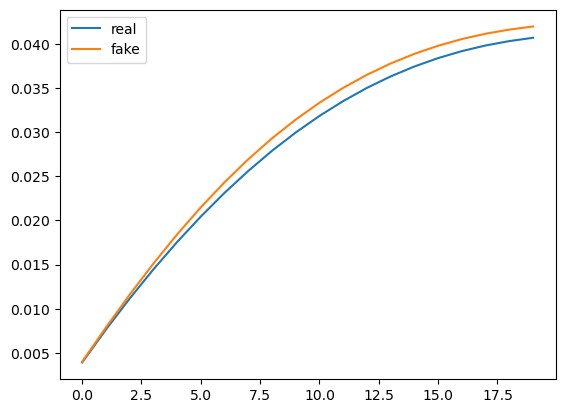

In [ ]:
plt.plot(rdists, label="real")
plt.plot(fdists, label="fake")
plt.legend()

In [ ]:
unet2d = tru.load_diffusion_model()

In [ ]:
run2d = evals.Run("diffusion_hp_search", "lr-explore", climsim_run = False, cid='best')
trainer = run2d.reconstruct_trainer(apply_checkpoints=True, apply_indices=False)

/srv/conda/envs/notebook/lib/python3.12/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
losses, self.loss_weights[run_id]

(tensor([1.5882e-02, 4.3194e+03, 4.1961e-02], device='cuda:0',
        grad_fn=<StackBackward0>),
 tensor([2.0310e-01, 1.6816e-04, 2.7967e+00], device='cuda:0',
        requires_grad=True))

In [ ]:
trainer.current_epoch = 7
trainer._return_loss_weights(tconfigs[3])

### Sanity Checking run_batch

In [ ]:
run = evals.Run()

In [ ]:
import copy

def params_of(model):
    return [p.detach().clone() for p in model.parameters()][-2]

In [ ]:
og_models = [copy.deepcopy(trainer.models[run_id]) for run_id in trainer.run_ids]

In [ ]:
import copy

for key in trainer.models:
    model = copy.deepcopy(og_models[0])
    tconfig = trainer.training_configs[key]
    trainer.models[key] = model
    print(params_of(trainer.models[key])[:2, :2], "\n")
    self.optimizers[key] = tru.create_optimizer(model, tconfig)


In [ ]:
x, y = next(iter(trainer.dataloaders['train']))

In [ ]:
import torch

initial_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    initial_weights[key] = param.detach().clone()

batch_losses, params, after_params = _run_batch(trainer, x, y, phase='train', step=0)
new_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    new_weights[key] = param.detach().clone()
    print(f"{key} updated:", not torch.allclose(param, initial_weights[key]))

In [ ]:
params[0] == after_params[0]

In [ ]:
after_params[0]

In [ ]:
self = trainer
for run_id, grads in self.gradients.items():
    print(run_id, trainer.training_configs[run_id].loss_weights)
    for loss_type, gradloss in grads.items():
        print(loss_type, gradloss['2.weight'])``
    print()

In [ ]:
[trainer.training_configs[run_id].num_gaussians for run_id in trainer.run_ids]

## Implementing GradNorm

In [ ]:
from collections import defaultdict
from sklearn.mixture import GaussianMixture
import math

In [ ]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    #dconfig = tru.my_dconfig("local_vzarr", "v1", in_notebook, False, "climsim")
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, shuffle_indices=False, 
                                batch_size=batch_size, use_tendencies=False,
                             )
    dconfig.train_test_split = [0.001, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 5e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.01, 0.1, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [10.0, 10.0, 10.0, 10.0]
    target_variables_distloss = 73 # [68, 73, 82] # previously included 60 asw
    num_gaussians = 2 # [3, 2, 3]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        loss_schedule = {'mse': 0, 'distribution': 1, 'diffusion': 1}
        tconfig.loss_weight_params.update( dict(strategy="fixed", weights=loss_weights, schedule=loss_schedule))
        tconfig.clip_gradients = False
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [ ]:

def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    shuffle_indices = False
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, shuffle_indices, 
                             dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [0.20, 0.05]
    tconfigs, mconfigs = [], []

    learning_rates = [5e-5, 1e-4, 5e-4, 1e-3, 2.5e-3]
    #diffloss_weights = [5.0, 5.0, 5.0, 5.0]
    #distloss_weights = [0.1, 0.1, 0.1, 0.1]
    target_variables_distloss = [73, 59, 123]
    num_gaussians = [2, 2, 2]
    
    #run_ids = f"{base_run_id}-mse {base_run_id}-diff {base_run_id}-dist {base_run_id}-joint".split()
    lettering = "abcdefghijklmnopqrstuvwxyz"
    run_ids = [f"{base_run_id}-{lettering[i]}" for i in range(num_models)]
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=run_ids[i])
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate_params.update({
            "base_learning_rate" : learning_rates[i] * batch_size / REF_BATCH_SIZE,
            "step_size" : 500,
            "gamma" : 0.95,
            "scheduler_type" : "steplr",
        })
        tconfig.loss_weight_params.update({
            "strategy" : "gradnorm",
            "update_interval" : 10,
            "alpha" : 0.5,
            "weights" : {'mse': 1.0, 'distribution': 0.1, 'diffusion': 5.0},
            "schedule" : {'mse': [0,100], 'distribution': 2 , 'diffusion': 2}
        })
        tconfig.clip_gradients = False
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.distloss_var_sel = "uniform"

        tconfig.diffusion_loss_noise_level = 20

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfig.batch_logging_interval = 16
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)


In [ ]:
class ModelLens:
    def __init__(self, model: torch.nn.Module):
        self.model = model
        self.params = dict(model.named_parameters())
        self.param_names = [p for p in self.params]
    
    def get_param(self, getter):
        if isinstance(getter, str):
            return self.params[getter]
        elif isinstance(getter, int):
            return self.params[self.param_names[getter]]
        raise ValueError(f"Invalid getter: {getter}")

    def __getattr__(self, name):
        return getattr(self.model, name)
    
    def __call__(self, *args):
        return self.model(*args)

    def __repr__(self):
        return repr(self.model)
    def __str__(self):
        return str(self.model)


In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    1, "MultiTask", "testing", data_vars='v1', batch_size= 128
)
dconfig.train_test_split = [0.001, 0.05]
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.001, 0.05],
           dataloader_params=DataLoaderParams(batch_size=49152,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=True),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


In [ ]:
dataloaders, indices = tru.load_dataloaders(dconfig, log=True)
dl, edl = dataloaders
train_indices, test_indices = indices

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [ ]:
trainer = trainers.ClimsimTrainer(dataloaders, indices, mconfigs, tconfigs, exp_dir, "testing", rank=0)

In [ ]:
trainer.train(1)

Getting ready to train 1 model(s) for 1 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/testing.json
Saving configs to /mnt/home/ssa2206/Climsim/experiments/testing.json


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: samart-agr to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0/0
__________


{"event": "epoch-0 start", "time": 1754633110.5588436, "pid": 403117}
{"event": "get-item start", "time": 1754633110.5621448, "pid": 403117, "batch_idx": 0}
{"event": "get-item end", "time": 1754633114.797018, "pid": 403117, "batch_idx": 0, "duration": 4.234867572784424}


avg mse loss for epoch 0, run_id='testing-a': 4.658846378326416
avg distribution loss for epoch 0, run_id='testing-a': 92.19037262617253
avg diffusion loss for epoch 0, run_id='testing-a': 0.07365454733371735
Finished training 1 model(s) for 1 epochs.


{"event": "epoch-0 end", "time": 1754633117.3648355, "pid": 403117, "duration": 6.805987596511841}


In [ ]:
x, y = next(iter(dl))

{"event": "get-item start", "time": 1754627340.9731824, "pid": 383885, "batch_idx": 0}
{"event": "get-item end", "time": 1754627345.3248062, "pid": 383885, "batch_idx": 0, "duration": 4.351618051528931}


In [ ]:
x, y = x.to(device), y.to(device)

In [ ]:
tconfigs[0].learning_rate

0.0041015625

In [ ]:
trainer = ClimsimTrainer([dl, edl], [indices], mconfigs, tconfigs, os.path.join(exp_dir, "MultiTask"), "testing", rank=0)
trainer.distloss_var_counts = {}
self = trainer
epochs = 10
self.setup_training(epochs, log=False)

Getting ready to train 1 model(s) for 10 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/MultiTask/testing.json
Saving configs to /mnt/home/ssa2206/Climsim/experiments/MultiTask/testing.json


In [ ]:
trainer.train(5, log=False)

Getting ready to train 1 model(s) for 5 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/MultiTask/testing.json
Saving configs to /mnt/home/ssa2206/Climsim/experiments/MultiTask/testing.json
Epoch 0/4
__________
avg mse loss for epoch 0, run_id='testinga': 4.632805824279785
avg distribution loss for epoch 0, run_id='testinga': 87.48641211512405
avg diffusion loss for epoch 0, run_id='testinga': 0.0734742060303688
Epoch 1/4
__________
avg mse loss for epoch 1, run_id='testinga': 4.622385740280151
avg distribution loss for epoch 1, run_id='testinga': 83.3295925853005
avg diffusion loss for epoch 1, run_id='testinga': 0.07328740879893303
Epoch 2/4
__________
avg mse loss for epoch 2, run_id='testinga': 4.602545499801636
avg distribution loss for epoch 2, run_id='testinga': 48.707311998701385
avg diffusion loss for epoch 2, run_id='testinga': 0.07293626666069031
Epoch 3/4
__________
avg mse loss for epoch 3, run_id='testinga': 4.582812070846558
avg distribution los

In [ ]:
run_id = self.run_ids[0]
epochs = 10
losses = []

for step in range(epochs):
    batch_losses = {run_id: {}}
    y_hat = self.models[run_id](x)
    loss = self.apply_loss(y_hat, x, y, batch_losses, run_id, step)
    losses.append(loss)
    self.optimizers[run_id].zero_grad()
    (self.loss_weights[run_id] @ loss).backward()
    self.optimizers[run_id].step()


In [ ]:
mweight = [t[0].item() for t in losses]
dweight = [t[1].item() for t in losses]
fweight = [t[2].item() for t in losses]
print(self.tracked_losses)

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=list(range(len(mweight))), y=mweight, name='mse'))
fig.add_trace(go.Scatter(x=list(range(len(dweight))), y=dweight, name='distribution'))
fig.add_trace(go.Scatter(x=list(range(len(fweight))), y=fweight, name='diffusion'))

['mse', 'distribution', 'diffusion']


In [ ]:
trainer.train(5, log=False)

Getting ready to train 2 model(s) for 5 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/MultiTask/testing.json
Saving configs to /mnt/home/ssa2206/Climsim/experiments/MultiTask/testing.json
Epoch 0/4
__________
avg mse loss for epoch 0, run_id='testinga': 4.60971212387085
avg distribution loss for epoch 0, run_id='testinga': 60.008416085366505
avg diffusion loss for epoch 0, run_id='testinga': 0.07296112179756165
avg mse loss for epoch 0, run_id='testingb': 4.622191667556763
avg distribution loss for epoch 0, run_id='testingb': 57.43321818472975
avg diffusion loss for epoch 0, run_id='testingb': 0.07054824754595757
Epoch 1/4
__________
avg mse loss for epoch 1, run_id='testinga': 4.587967872619629
avg distribution loss for epoch 1, run_id='testinga': 56.8403376709223
avg diffusion loss for epoch 1, run_id='testinga': 0.07257289066910744
avg mse loss for epoch 1, run_id='testingb': 4.574346542358398
avg distribution loss for epoch 1, run_id='testingb': 27.88883

In [ ]:


fig.show()
    

['mse', 'distribution', 'diffusion']


In [ ]:
run = evals.Run("MultiTask", "testing")

Checkpoint /mnt/home/ssa2206/Climsim/experiments/MultiTask/checkpoints/best-testinga-ckpt.pt was deleted
Checkpoint /mnt/home/ssa2206/Climsim/experiments/MultiTask/checkpoints/best-testingb-ckpt.pt was deleted


In [ ]:
trainer.models['testinga'].param_names

['0.weight',
 '0.bias',
 '2.weight',
 '2.bias',
 '4.weight',
 '4.bias',
 '6.weight',
 '6.bias']

In [ ]:
evals.plot_gradients(run, "mse", '4.weight')

NameError: name 'run' is not defined

In [ ]:
dl = iter(self.dataloaders['train'])
trainer.setup_training(2, log=False)

NameError: name 'self' is not defined

In [ ]:
x, y = next(dl)

image_dim is None, returning original tensor
image_dim is None, returning original tensor


In [ ]:
batch_losses = self._run_batch(x.to(self.device), y.to(self.device), 'train', 0)


 testinga
losses: tensor([4.6282, 0.7851, 0.0713], device='cuda:0', dtype=torch.float64,
       grad_fn=<StackBackward0>)
loss_weights: tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64)
loss weights before update
 Parameter containing:
tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64,
       requires_grad=True)
loss weights after update
 Parameter containing:
tensor([0.2025, 0.1292, 2.7009], device='cuda:0', dtype=torch.float64,
       requires_grad=True)
loss weights after updat and norm
 Parameter containing:
tensor([0.2129, 0.1978, 2.5893], device='cuda:0', dtype=torch.float64,
       requires_grad=True)

 testingb
losses: tensor([4.6319e+00, 7.9094e+01, 7.2605e-02], device='cuda:0',
       dtype=torch.float64, grad_fn=<StackBackward0>)
loss_weights: tensor([0.1641, 0.1462, 2.6897], device='cuda:0', dtype=torch.float64)
loss weights before update
 Parameter containing:
tensor([0.1641, 0.1462, 2.6897], device='cuda:0', dtype=torch.float64,
 

In [ ]:
batch_losses = self._run_batch(x.to(self.device), y.to(self.device), 'train', 0)


 testinga
losses: tensor([ 4.6488, 14.4846,  0.0746], device='cuda:0', dtype=torch.float64,
       grad_fn=<StackBackward0>)
loss_weights: tensor([0.1851, 0.1607, 2.6542], device='cuda:0', dtype=torch.float64)
loss weights before update
 Parameter containing:
tensor([0.1851, 0.1607, 2.6542], device='cuda:0', dtype=torch.float64,
       requires_grad=True)


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [ ]:
run_id = 'testinga'
self.loss_weights[run_id], self.loss_weights[run_id].grad_fn, self.loss_weights[run_id].grad

(Parameter containing:
 tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64,
        requires_grad=True),
 None,
 tensor([-4.6924e-01,  2.4750e+02, -2.6382e-02], device='cuda:0',
        dtype=torch.float64))

In [ ]:
batch_losses

{'testinga': {'mse': tensor(4.6504, device='cuda:0', grad_fn=<MseLossBackward0>),
  'VAR_IND': 73,
  'distribution': tensor(68.9273, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
  'diffusion': tensor(0.0715, device='cuda:0', grad_fn=<MseLossBackward0>),
  'total': 0.966773894154823},
 'testingb': {'mse': tensor(4.6203, device='cuda:0', grad_fn=<MseLossBackward0>),
  'VAR_IND': 73,
  'distribution': tensor(82.4331, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
  'diffusion': tensor(0.0716, device='cuda:0', grad_fn=<MseLossBackward0>),
  'total': 1.14814804429708}}

In [ ]:
self.log_step(batch_losses, 0, "train", False)

In [ ]:
x, y = next(dl)

image_dim is None, returning original tensor
image_dim is None, returning original tensor


In [ ]:
self.L0['testinga']

{'l0': tensor([ 4.6504, 68.9273,  0.0715], device='cuda:0', dtype=torch.float64),
 73: tensor(68.9273, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>)}

In [ ]:
print("\n", run_id)
batch_losses[run_id] = {}
y_hat = self.models[run_id](x.to(device)) 
losses = self.apply_loss(y_hat, x, y.to(device), batch_losses, run_id, step=1)
print("losses:", losses)
loss_weights = self._return_loss_weights(run_id, batch_losses[run_id])
print("loss_weights:", loss_weights)
total_loss = loss_weights @ losses


 testinga
losses: tensor([4.6625e+00, 1.2034e+02, 7.1509e-02], device='cuda:0',
       dtype=torch.float64, grad_fn=<StackBackward0>)
loss_weights: tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64)


In [ ]:
losses

tensor([4.6625e+00, 1.2034e+02, 7.1509e-02], device='cuda:0',
       dtype=torch.float64, grad_fn=<StackBackward0>)

In [ ]:
self.loss_weights['testinga']

Parameter containing:
tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64,
       requires_grad=True)

In [ ]:
self._update_gradnorm_weights(run_id, batch_losses[run_id])

loss weights before update Parameter containing:
tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64,
       requires_grad=True)
loss weights after update Parameter containing:
tensor([0.2025, 0.1222, 2.7009], device='cuda:0', dtype=torch.float64,
       requires_grad=True)


In [ ]:
self.optimizers[run_id].zero_grad()
total_loss.backward(retain_graph=False)

In [ ]:
self.lw_history[run_id]

[tensor([1.4279e-01, 1.4279e-03, 2.8558e+00], device='cuda:0',
        dtype=torch.float64),
 tensor([0.1775, 0.1466, 2.6759], device='cuda:0', dtype=torch.float64)]

In [ ]:
trainer.dirs

{'log_dir': '/mnt/home/ssa2206/Climsim/experiments/MultiTask',
 'ckpt_dir': '/mnt/home/ssa2206/Climsim/experiments/MultiTask/checkpoints/testing',
 'output_dir': '/mnt/home/ssa2206/Climsim/experiments/MultiTask/outputs/testing'}

In [ ]:
tconfig = self.training_configs[run_id]
pprint(tconfig)

TrainingConfig(exp_id='MultiTask',
               run_id='testingb',
               num_epochs=2,
               phases=['train', 'eval'],
               distributed_training=False,
               optimizer='adam',
               betas=(0.9, 0.999),
               lr_scheduler=None,
               learning_rate=0.00025,
               loss_weight_params={'T': 3.0,
                                   'alpha': 0.5,
                                   'gradnorm_layer': -2,
                                   'lr': 0.025,
                                   'schedule': {'diffusion': 1,
                                                'distribution': 1,
                                                'mse': 0},
                                   'strategy': 'gradnorm',
                                   'update_interval': 5,
                                   'weights': {'diffusion': 40.0,
                                               'distribution': 0.1,
                                       

In [ ]:
y_hat

NameError: name 'y_hat' is not defined

In [ ]:
self.setup_training(5, log=False)
run = evals.Run("DiffLossTesting",  "trial4")
for j, run_id in enumerate(self.run_ids):
    self.losses[run_id] = run.get("losses", j)
    ldict = self.losses[run_id]['train']
    choices = self.training_configs[run_id].distloss_var_inds
    ldict['distloss_var'] = list(np.random.choice(choices, size=len(ldict['distribution'])))
    self.L0[run_id]['l0'] = torch.tensor([ldict[l][0] for l in self.tracked_losses]).to(self.device)
    for i, var in enumerate(ldict['distloss_var']):
        if var not in self.L0[run_id]:
            self.L0[run_id][var] = torch.tensor(ldict['distribution'][i])

self.L0

Getting ready to train 2 model(s) for 5 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/MultiTask/testing.json


{'testinga': {'l0': tensor([4.5794e+00, 9.1391e+01, 7.4890e-02], device='cuda:0'),
  np.int64(68): tensor(91.3914),
  np.int64(82): tensor(0.5397),
  np.int64(73): tensor(8.4719)},
 'testingb': {'l0': tensor([4.6067, 1.3986, 0.0730], device='cuda:0'),
  np.int64(73): tensor(1.3986),
  np.int64(68): tensor(0.2611),
  np.int64(82): tensor(3.9456)}}

In [ ]:
run_ids = trainer.run_ids
run_id = run_ids[0]
model, optimizer, tconfig = self.models[run_id], self.optimizers[run_id], self.training_configs[run_id]
y_hat = model(x)
y_hat.shape

torch.Size([49152, 128])

In [ ]:
batch_losses = {run_id:{}}
losses = self.apply_loss(y_hat, x, y, batch_losses, run_id, step=0)
batch_losses = batch_losses[run_id]
losses, batch_losses

(tensor([4.2988e-02, 2.9295e+04, 7.1110e-02], device='cuda:0',
        dtype=torch.float64, grad_fn=<StackBackward0>),
 {'mse': tensor(0.0430, device='cuda:0', grad_fn=<MseLossBackward0>),
  'VAR_IND': 82,
  'distribution': tensor(29294.6312, device='cuda:0', dtype=torch.float64,
         grad_fn=<DivBackward0>),
  'diffusion': tensor(0.0711, device='cuda:0', grad_fn=<MseLossBackward0>)})

In [ ]:
params = self.training_configs[run_id].loss_weight_params
W = self.loss_weights[run_id]
losses = torch.stack([batch_losses[l].detach() for l in self.tracked_losses])
l0 = self.L0[run_id]['l0']
if "VAR_IND" in batch_losses and batch_losses['VAR_IND'] in self.L0[run_id]:
    i = self.tracked_losses.index("distribution")
    l0[i] = self.L0[run_id][batch_losses['VAR_IND']]
loss_ratio = losses / l0
grads = []
param = self.models[run_id].get_param(params['gradnorm_layer'])
for i, loss_type in enumerate(self.tracked_losses):
    grad = torch.autograd.grad(W[i] * batch_losses[loss_type], param, retain_graph=True, create_graph=True)[0]
    grads.append(torch.norm(grad))
grads = torch.stack(grads)
target_grads = grads.detach().mean() * (loss_ratio / loss_ratio.mean()) ** params['alpha']
gradnorm_loss = self.gradnorm_loss_fn(grads, target_grads)
print("loss weights before update", self.loss_weights[run_id])
self.lw_optimizers[run_id].zero_grad()
gradnorm_loss.backward()
self.lw_optimizers[run_id].step()
print("loss weights after update", self.loss_weights[run_id])

loss weights before update Parameter containing:
tensor([1.4279e-01, 1.4279e-03, 2.8558e+00], device='cuda:0',
       dtype=torch.float64, requires_grad=True)
loss weights after update Parameter containing:
tensor([ 1.4529e-01, -1.0721e-03,  2.8583e+00], device='cuda:0',
       dtype=torch.float64, requires_grad=True)


In [ ]:
datasets

In [ ]:
self.dataloaders['train'].dataset = datasets[0]

ValueError: dataset attribute should not be set after DataLoader is initialized

In [ ]:
W

Parameter containing:
tensor([0.1771, 0.1530, 2.6699], device='cuda:0', dtype=torch.float64,
       requires_grad=True)

In [ ]:
with torch.no_grad():
    W.mul_(1.1)# = torch.nn.functional.softmax(W) * params['T']
    print(W)

Parameter containing:
tensor([ 1.7580e-01, -1.2973e-03,  3.4585e+00], device='cuda:0',
       dtype=torch.float64, requires_grad=True)


In [ ]:
self.loss_weights[run_id] is W

True

In [ ]:
#self._update_gradnorm_weights(run_id, batch_losses)
loss_weights = self._return_loss_weights(run_id, batch_losses)
loss_weights @ losses

tensor(4482.2669, device='cuda:0', dtype=torch.float64)

In [ ]:
softmax = lambda x : torch.nn.functional.softmax(torch.tensor(x), dim=0)
softplus = lambda x : torch.nn.functional.softplus(torch.tensor(x)) / torch.nn.functional.softplus(torch.tensor(x)).sum()
#
# softmax([0.01, 0.01, 5])
x = [1e-4, -4, 0.84]
print(softmax(x), softplus(x))


tensor([0.2999, 0.0055, 0.6946]) tensor([0.3629, 0.0095, 0.6276])


In [ ]:
W.grad_fn

In [ ]:
torch.nn.functional.softplus(W)

tensor([0.7684, 0.6926, 2.9141], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftplusBackward0>)

In [ ]:
torch.nn.functional.softmax(W)

/tmp/ipykernel_846051/2306342748.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  torch.nn.functional.softmax(W)


tensor([0.0590, 0.0510, 0.8900], device='cuda:0', dtype=torch.float64,
       grad_fn=<SoftmaxBackward0>)

In [ ]:
with torch.no_grad():
    Ws = torch.nn.functional.softplus(W)
    Ws *= params['T'] / (Ws.sum() + 1e-7)
    print(Ws)

tensor([0.5269, 0.4749, 1.9982], device='cuda:0', dtype=torch.float64)


In [ ]:
with torch.no_grad():
    Ws = torch.nn.functional.softmax(W, dim=0) * params['T']
    print(Ws)

tensor([0.1771, 0.1530, 2.6699], device='cuda:0', dtype=torch.float64)


In [ ]:
grads, target_grads

(tensor([1.9404e-03, 5.5149e+02, 1.5395e-02], device='cuda:0',
        grad_fn=<StackBackward0>),
 tensor([  2.8435, 317.0862,  28.8727], device='cuda:0', dtype=torch.float64))

In [ ]:
self.L0[run_id]['l0'].device

device(type='cpu')

In [ ]:
params = self.training_configs[run_id].loss_weight_params
W = self.loss_weights[run_id]
losses = torch.stack([batch_losses[run_id][l].detach() for l in self.tracked_losses])
l0 = self.L0[run_id]['l0']
print(l0)
if "VAR_IND" in batch_losses[run_id] and batch_losses[run_id]['VAR_IND'] in self.L0[run_id]:
    i = self.tracked_losses.index("distribution")
    print(i, batch_losses[run_id]['VAR_IND'])
    print(self.L0[run_id][batch_losses[run_id]['VAR_IND']])
    print(l0[i])




tensor([[4.5794e+00, 9.1391e+01, 7.4890e-02]])
1 82
tensor(-3.2564)


IndexError: index 1 is out of bounds for dimension 0 with size 1

In [ ]:
self.L0[run_id]

{'l0': tensor([[4.5794e+00, 9.1391e+01, 7.4890e-02]]),
 np.int64(73): tensor(91.3914),
 np.int64(68): tensor(0.5397),
 np.int64(82): tensor(-3.2564)}

In [ ]:
batch_losses

{'testinga': {'mse': tensor(0.0436, device='cuda:0', grad_fn=<MseLossBackward0>),
  'VAR_IND': 82,
  'distribution': tensor(40507.3984, device='cuda:0', dtype=torch.float64,
         grad_fn=<DivBackward0>),
  'diffusion': tensor(0.0707, device='cuda:0', grad_fn=<MseLossBackward0>)}}

In [ ]:
step = 0
batch_losses = {run_id : {}}
print(self.tracked_losses, "\n\n")
losses = torch.stack([self.apply_loss(y_hat, x, y, loss_type, batch_losses, run_id, step) for loss_type in self.tracked_losses])

batch_losses = batch_losses['testinga']
batch_losses

['mse', 'distribution', 'diffusion'] 


73


{'mse': tensor(0.0448, device='cuda:0', grad_fn=<MseLossBackward0>),
 'VAR_IND': 73,
 'distribution': tensor(4152.1830, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
 'diffusion': tensor(0.0708, device='cuda:0', grad_fn=<MseLossBackward0>)}

In [ ]:
params = self.training_configs[run_id].loss_weight_params
W = self.loss_weights[run_id]
losses, VAL_IND = torch.stack([batch_losses[l].detach() for l in self.tracked_losses]), batch_losses['VAR_IND']
print(VAL_IND)
l0 = self.L0[run_id].get(VAL_IND, None)
if l0 is None:
    l0 = list(self.L0[run_id].values())[0] if len(self.L0[run_id]) > 0 else torch.ones_like(losses)
loss_ratio = losses / l0.to(losses.device)
loss_ratio ** 0.5

68


tensor([ 0.2117, 63.9347,  0.2663], device='cuda:0', dtype=torch.float64)

In [ ]:
grads = []
param = self.models[run_id].get_param(params['gradnorm_layer'])
for i, loss_type in enumerate(self.tracked_losses):
    grad = torch.autograd.grad(W[i] * batch_losses[loss_type], param, retain_graph=True, create_graph=True)[0]
    print(torch.norm(torch.autograd.grad(batch_losses[loss_type], param, retain_graph=True, create_graph=True)[0]).item())
    grads.append(torch.norm(grad))
grads = torch.stack(grads)
grads

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [ ]:
target_grads = grads.detach().mean() * (loss_ratio / loss_ratio.mean()) ** 0.1
gradnorm_loss = self.gradnorm_loss_fn(grads, target_grads)
gradnorm_loss, target_grads, grads

(tensor(503.7187, device='cuda:0', dtype=torch.float64, grad_fn=<SumBackward0>),
 tensor([ 61.7076, 223.3988,  64.9819], device='cuda:0', dtype=torch.float64),
 tensor([2.2250e-03, 6.0045e+02, 1.8035e-02], device='cuda:0',
        grad_fn=<StackBackward0>))

In [ ]:
print("loss weights before update", self.loss_weights[run_id])
self.lw_optimizers[run_id].zero_grad()
gradnorm_loss.backward()
self.lw_optimizers[run_id].step()
print("loss weights after update", self.loss_weights[run_id])
with torch.no_grad():
    W.mul_(params['T'] / W.sum())

loss weights before update Parameter containing:
tensor([1.4279e-01, 1.4279e-03, 2.8558e+00], requires_grad=True)
loss weights after update Parameter containing:
tensor([ 0.1678, -0.0236,  2.8808], requires_grad=True)


In [ ]:
W, self.loss_weights[run_id]

(Parameter containing:
 tensor([ 0.3328, -0.0468,  5.7139], requires_grad=True),
 Parameter containing:
 tensor([ 0.3328, -0.0468,  5.7139], requires_grad=True))

In [ ]:
(loss_ratio / loss_ratio.mean()) ** 0.1

tensor([0.3206, 1.1161, 0.3388], device='cuda:0', dtype=torch.float64)

In [ ]:
self.L0[run_id][73] = torch.tensor([self.losses['testinga']['train'][l][0] for l in self.tracked_losses])

False

In [ ]:
print("mse : ", self.losses[run_id]['train']['mse'][:3])
print("distribution : ", self.losses[run_id]['train']['distribution'][:6])
print("diffusion : ", self.losses[run_id]['train']['diffusion'][:3])


print(self.losses[run_id]['train']['distloss_var'][:7])

mse :  [4.579434871673584, 1.5953820943832397, 0.5841066241264343]
distribution :  [91.39145117909806, 0.5397367975602321, 8.471865611125404, 0.2730342224641375, 0.008982313014709009, -3.256379498835006]
diffusion :  [0.07489027082920074, 0.052291955798864365, 0.047195278108119965]
[np.int64(82), np.int64(73), np.int64(68), np.int64(73), np.int64(68), np.int64(73), np.int64(68)]


In [ ]:
loss_ratios

tensor([9.9237e-01, 6.9291e-04, 9.5203e-01], device='cuda:0')

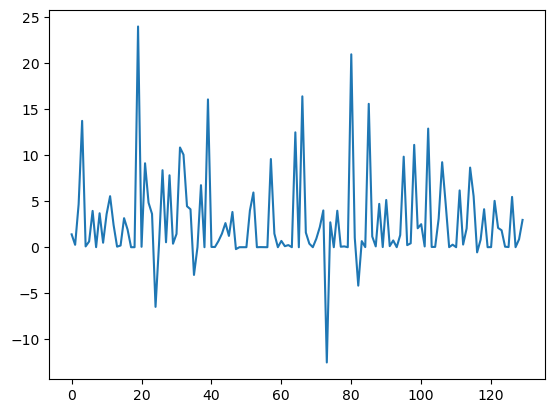

In [ ]:
plt.plot(self.losses[run_id]['train']['distribution'])

In [ ]:
run.logs['trial4-joint'].keys()

dict_keys(['training_config', 'model_config', 'train_epoch_losses', 'losses', 'gradients', 'distloss_var_counts'])

In [ ]:
self.losses[run_id]["train"].keys() # ["mse"][0]

dict_keys(['mse', 'total', 'diffusion', 'distribution'])

In [ ]:
plt.plot(self.losses[run_id]["train"]["mse"])

In [ ]:
losses.dtype

tensor([4.5432e+00, 1.3915e+02, 7.4138e-02], device='cuda:0',
       dtype=torch.float64, grad_fn=<StackBackward0>)

In [ ]:
trainer.loss_weights['testinga'].type(torch.float64) @ losses

tensor(7.4175, device='cuda:0', dtype=torch.float64, grad_fn=<DotBackward0>)

In [ ]:
grad_norms, ratios = self._return_loss_weights(run_id, losses)

In [ ]:
d = {}

d.get('a', 0)

0

In [ ]:
[self.losses[run_id]["train"][l][0] for l in self.tracked_losses]

[4.606654167175293, 1.3985665072812157, 0.07303743809461594]

In [ ]:
ratios

tensor([0.9415, 0.1190, 0.9759], device='cuda:0')

# Training behavior  - Diffusion

# Training Behavior - Climsim

In [ ]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [0.001, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.0, 0.0, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [0.0, 10.0, 0.0, 10.0]
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3, 2]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        tconfig.loss_schedule = {'mse': 0, 'distribution': 5, 'diffusion': 5}
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64
)

trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, 
                torch.nn.MSELoss(), base_dir, run_id, rank=0)

## Validating Errors

Including incidents of nan or anything else

In [ ]:
def score_function(x, mu, var, pi, clamp_val=10, epsilon=1e-7):
    mahal = (x[:,None] - mu) ** 2 / (2 * var)
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - torch.clamp(mahal, max=clamp_val)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True)) + epsilon
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * torch.clamp((x[:,None] - mu) / var, max=clamp_val, min=-clamp_val)  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()

def u_q(x_1, x_2, mu, var, pi, h):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    print(sq1.isnan().any(), sq2.isnan().any())

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    
    diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
    res = torch.outer(sq1, sq2)
    res += (sq1.reshape(-1,1) * diffs) / h**2
    res -= (sq2.reshape(1, -1) * diffs)/h**2
    res += (h**-2 - h**-4 * diffs ** 2)
    res = res * torch.exp(- (diffs ** 2) / (2 * h ** 2)) # kernel matrix
    return(res)

In [ ]:
trainer.bli = 1
trainer.train(1, log=True)

### Investigating Incidents

In [ ]:
from diffusionsim.evaluations import *

In [ ]:
incident  = trainer.nan_incidents['trial1b'][0]
print(incident.keys())
for name, p in incident['state_dict'].items():
    print(name, p.shape, torch.isnan(p).any())



In [ ]:
sample_model = tru.build_baseline_model(mconfigs[0]).to(device)
sample_model.eval()
sample_model.load_state_dict(incident['state_dict'])


In [ ]:
x, y = trainer.dataloaders['train'].dataset[335]
x, y = x.to(device), y.to(device)
y_hat = sample_model(x)
print(y_hat.shape, y.shape)
distribution_loss(trainer, y_hat, y, tconfigs[0], 0) # nan? 

In [ ]:
plt.hist(y[:, VAR_IND].detach().cpu().numpy(), bins=50, density=True, alpha=0.5, label='Data')
plt.show()

In [ ]:
x = torch.linspace(-2, 0, 1000)
density, = eval_density(x, GMM)
plt.plot(x, density)

In [ ]:
d = plot_gmm_distribution(y[:,VAR_IND].reshape(-1, 1), GMM)

In [ ]:
means_grads = {}
stds_grads = {}

for k in trainer.gradients['trial1d'].keys():
    means_grads[k] = []
    stds_grads[k] = []
    loss_grads = trainer.gradients['trial1d'][k]
    for name, stats in loss_grads.items():
        if(name == '2.weight'):
            for mean, std in stats:
                means_grads[k].append(mean)
                stds_grads[k].append(std)

# Trying to Improve Training

## Overfitting two samples

two_sample_ds = ClimsimImageDataset(Xarr[:2*384], Yarr[:2*384], mconfig, device=device, normalize=True)

In [ ]:
#two_sample_dl = DataLoader(two_sample_ds, shuffle=tconfig.shuffle_data['train'], batch_size=2)
two_sample_dl = DataLoader(two_sample_ds, shuffle=tconfig.shuffle_data['train'], batch_size=2)
batch = next(iter(two_sample_dl))
noisy_images, timesteps, noise = two_sample_dl.dataset.noise_batch(batch)

optimizer = diff.trainers.create_optimizer(model, tconfig)
lr_scheduler = load_lr_scheduler(tconfig, optimizer, two_sample_dl)

In [ ]:
pred = model(noisy_images, timesteps).sample
loss = loss_fn(pred, noise)
loss

NameError: name 'noisy_images' is not defined

In [ ]:
loss.backward()

In [ ]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

In [ ]:
torch.norm(list(model.parameters())[0].grad)

In [ ]:
set = {'train' : two_sample_ds}
trainer = DiffusionTrainer(model, dset, loss_fn, tconfig, mconfig, exp_id='two_sample_diffusion')
#trainer.dataloaders = {'train' : two_sample_dl}
#trainer.batch = next(iter(two_sample_dl)) # use same noise every time
trainer.train(1000)

In [ ]:
plt.plot(trainer.losses)

## 

In [ ]:
from diffusers.optimization import get_cosine_schedule_with_warmup

optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = load_lr_scheduler(tconfig, )

## Experimenting with Accelerators

In [ ]:
from diffusers import DDPMPipeline
from diffusers.utils import make_image_grid
from accelerate import Accelerator
from huggingface_hub import create_repo, upload_folder
from tqdm.auto import tqdm
from pathlib import Path

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.Generator(device=device).manual_seed(config.seed), # Use a separate torch generator to avoid rewinding the random state of the main training loop
    ).images

    # Make a grid out of the images
    image_grid = make_image_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [ ]:
def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        #log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs"),
    )
    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=config.hub_model_id or Path(config.output_dir).name, exist_ok=True
            ).repo_id
        accelerator.init_trackers("train_example")


    # Prepare everything
    # There is no specific order to remember, you just need to unpack the
    # objects in the same order you gave them to the prepare method.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    # Now you train the model
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, clean_images in enumerate(train_dataloader):
            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape, device=clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device,
                dtype=torch.int64
            )

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        try:
            if accelerator.is_main_process:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
    
                if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                    evaluate(config, epoch, pipeline)
    
                if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                    if config.push_to_hub:
                        upload_folder(
                            repo_id=repo_id,
                            folder_path=config.output_dir,
                            commit_message=f"Epoch {epoch}",
                            ignore_patterns=["step_*", "epoch_*"],
                        )
                    else:
                        pipeline.save_pretrained(config.output_dir)
        except: 
            print("Ran into error with sampling and evaluating")
        
        return(model)

In [ ]:
from accelerate import notebook_launcher

args = (config, model, noise_scheduler, optimizer, dataloader, lr_scheduler)

model = notebook_launcher(train_loop, args, num_processes=1)